# NALA Warehouse Dashboard

> *"Make Money Move."* — Building payments for **#TheNextBillion**

NALA is an African-founded cross-border payments fintech running a **consumer remittance app** (diaspora → Africa/Asia) and **Rafiki**, a B2B stablecoin-settlement API. This notebook reads directly from the `analytics_marts` schema of the `nala_warehouse` (the dbt-built warehouse) and presents three executable use cases:

1. **Revenue & transfer volume** — Finance
2. **Compliance risk exposure** — Risk / MLRO
3. **Marketing efficiency / CAC** — Growth

Every KPI and chart below is computed live against the warehouse. The reporting window of interest is **Q1 2026 (2026-01-01 → 2026-03-31)**; underlying data spans 2018 → 2026-06-18.

## Config — connection + query helper

Single source of truth for the DB connection and the `q(sql) -> DataFrame` helper used by every cell below.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
from sqlalchemy import create_engine, text

# Render charts inline so nbconvert embeds them as PNG outputs
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# --- Warehouse connection -------------------------------------------------
DB = dict(host="localhost", port=5602, dbname="nala_warehouse", user="nala", password="nala_dev_only")
MARTS = "analytics_marts"

engine = create_engine(
    f"postgresql+psycopg2://{DB['user']}:{DB['password']}@{DB['host']}:{DB['port']}/{DB['dbname']}"
)


def q(sql: str) -> pd.DataFrame:
    """Run a read-only SQL string and return a DataFrame."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)


# Reporting window
Q1_START, Q1_END = "2026-01-01", "2026-03-31"

# Sanity check
_chk = q(f"select count(*) AS n from {MARTS}.fct_revenue_daily")
print(f"Connected to {DB['dbname']} — fct_revenue_daily rows: {int(_chk.n.iloc[0]):,}")


def money(x):
    return f"{x:,.0f}"

Connected to nala_warehouse — fct_revenue_daily rows: 126,588


---
## Use Case 1 — Revenue & Transfer Volume (Finance)

How much revenue does NALA generate, and where does it come from? Revenue is the sum of **transfer fees + FX margin**. We headline Q1 2026 total revenue, then look at the long-run monthly trend and the highest-earning corridors (currency pairs).

In [2]:
# KPI: total revenue for Q1 2026
uc1_kpi = q(f"""
    select
        sum(total_revenue)            as total_revenue,
        sum(transfer_count)           as transfer_count,
        sum(completed_transfer_count) as completed_transfer_count
    from {MARTS}.fct_revenue_daily
    where revenue_date between '{Q1_START}' and '{Q1_END}'
""")

uc1_total = float(uc1_kpi.total_revenue.iloc[0])
uc1_transfers = int(uc1_kpi.transfer_count.iloc[0])
uc1_completed = int(uc1_kpi.completed_transfer_count.iloc[0])

print("=== USE CASE 1 — KPI ===")
print(f"Q1 2026 total revenue : {money(uc1_total)}  (fee + FX margin, blended currency units)")
print(f"Q1 2026 transfers     : {uc1_transfers:,}  ({uc1_completed:,} completed)")


=== USE CASE 1 — KPI ===
Q1 2026 total revenue : 4,111,202  (fee + FX margin, blended currency units)
Q1 2026 transfers     : 365,162  (321,476 completed)


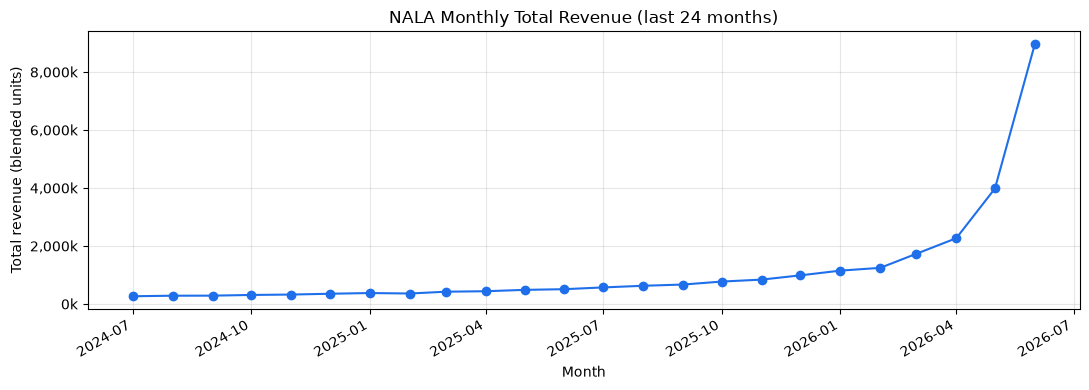

In [3]:
# Monthly revenue trend (last ~24 months)
uc1_trend = q(f"""
    select date_trunc('month', revenue_date)::date as month,
           sum(total_revenue) as revenue
    from {MARTS}.fct_revenue_daily
    group by 1
    order by 1
""")
uc1_trend = uc1_trend.tail(24)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(uc1_trend["month"], uc1_trend["revenue"], marker="o", color="#1f6feb")
ax.set_title("NALA Monthly Total Revenue (last 24 months)")
ax.set_xlabel("Month")
ax.set_ylabel("Total revenue (blended units)")
ax.grid(True, alpha=0.3)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, p: f"{v/1e3:,.0f}k"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


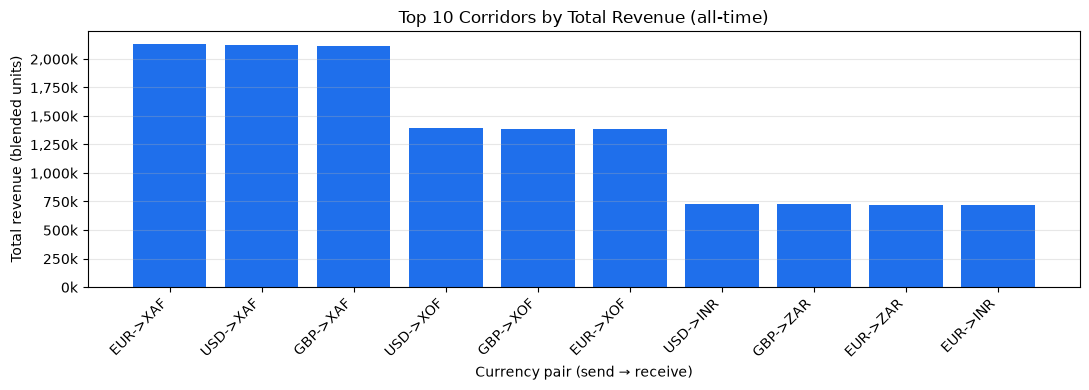

In [4]:
# Top corridors by revenue (all-time)
uc1_corr = q(f"""
    select currency_pair, sum(total_revenue) as revenue
    from {MARTS}.fct_revenue_daily
    group by 1
    order by 2 desc
    limit 10
""")

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(uc1_corr["currency_pair"], uc1_corr["revenue"], color="#1f6feb")
ax.set_title("Top 10 Corridors by Total Revenue (all-time)")
ax.set_xlabel("Currency pair (send → receive)")
ax.set_ylabel("Total revenue (blended units)")
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, p: f"{v/1e3:,.0f}k"))
plt.xticks(rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation.** Q1 2026 revenue is driven almost entirely by **fee + FX margin** on completed transfers — consistent with NALA's stated model of small/zero transfer fees plus a modest FX markup. The monthly trend shows the growth ramp from the early Tanzania years into the 2025–26 scale-up. Revenue concentrates in **→XAF and →XOF (West/Central Africa CFA franc)** corridors from EUR/USD/GBP send markets, confirming that the European and US diaspora into Francophone Africa is NALA's revenue core. (Revenue is reported in blended currency units across corridors — treat cross-corridor totals as directional, not a single-currency P&L figure.)

---
## Use Case 2 — Compliance Risk Exposure (Risk / MLRO)

NALA's moat is heavy licensing and owned compliance. The MLRO needs a live view of the customer risk book and KYC throughput. We headline the **high-risk customer share** and **sanctions hits**, then break down the full risk-band distribution and KYC outcomes.

In [5]:
# KPI: high-risk share + sanctions count
uc2_kpi = q(f"""
    select
        count(*)                                            as total_customers,
        count(*) filter (where risk_band = 'high')          as high_risk,
        count(*) filter (where sanctions_flag)              as sanctions,
        count(*) filter (where pep_flag)                    as pep,
        count(*) filter (where adverse_media_flag)          as adverse_media
    from {MARTS}.dim_customer_risk
""")

uc2_total = int(uc2_kpi.total_customers.iloc[0])
uc2_high = int(uc2_kpi.high_risk.iloc[0])
uc2_sanc = int(uc2_kpi.sanctions.iloc[0])
uc2_high_pct = 100.0 * uc2_high / uc2_total

print("=== USE CASE 2 — KPI ===")
print(f"Customers scored        : {uc2_total:,}")
print(f"High-risk band          : {uc2_high:,}  ({uc2_high_pct:.1f}% of book)")
print(f"Sanctions-flagged        : {uc2_sanc:,}")
print(f"PEP-flagged             : {int(uc2_kpi.pep.iloc[0]):,}")
print(f"Adverse-media-flagged   : {int(uc2_kpi.adverse_media.iloc[0]):,}")


=== USE CASE 2 — KPI ===
Customers scored        : 60,000
High-risk band          : 5,074  (8.5% of book)
Sanctions-flagged        : 479
PEP-flagged             : 1,774
Adverse-media-flagged   : 2,966


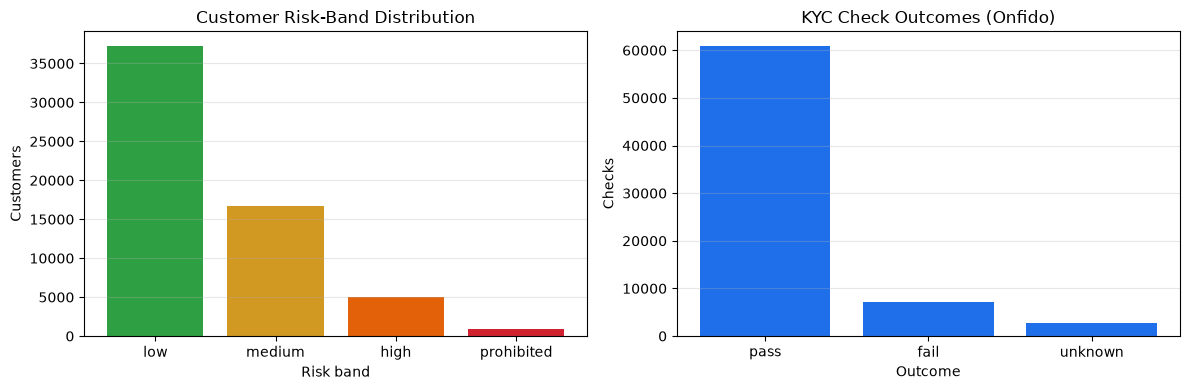

In [6]:
# Risk band distribution
uc2_bands = q(f"""
    select risk_band, count(*) as customers
    from {MARTS}.dim_customer_risk
    group by 1
""")
order = ["low", "medium", "high", "prohibited"]
uc2_bands["_o"] = uc2_bands["risk_band"].apply(lambda b: order.index(b) if b in order else 99)
uc2_bands = uc2_bands.sort_values("_o")

# KYC outcome breakdown
uc2_kyc = q(f"""
    select outcome, count(*) as checks
    from {MARTS}.fct_kyc_checks
    group by 1
    order by 2 desc
""")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {"low": "#2ea043", "medium": "#d29922", "high": "#e36209", "prohibited": "#cf222e"}
axes[0].bar(uc2_bands["risk_band"], uc2_bands["customers"],
            color=[colors.get(b, "#8b949e") for b in uc2_bands["risk_band"]])
axes[0].set_title("Customer Risk-Band Distribution")
axes[0].set_xlabel("Risk band")
axes[0].set_ylabel("Customers")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(uc2_kyc["outcome"], uc2_kyc["checks"], color="#1f6feb")
axes[1].set_title("KYC Check Outcomes (Onfido)")
axes[1].set_xlabel("Outcome")
axes[1].set_ylabel("Checks")
axes[1].grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation.** The overwhelming majority of the customer book sits in the **low** risk band, with a small but material **high-risk** tail and a hard **prohibited** segment that should be blocked from transacting. **Sanctions hits** are rare in absolute terms but are the highest-severity exposure — every one requires MLRO review and likely a SAR/SARS filing. KYC throughput is healthy (most checks **pass**), but the **fail** and **unknown** outcomes represent re-verification and manual-review backlog that Risk Ops must clear before those users can transact.

---
## Use Case 3 — Marketing Efficiency / CAC (Growth)

Growth needs to know what it costs to acquire a paying customer. We compute **blended CAC for Q1 2026** = total marketing spend ÷ new customers acquired (customers whose **first transfer** landed in Q1 2026), then show spend by channel and the CAC trend.

In [7]:
# KPI: blended CAC for Q1 2026
uc3_spend = q(f"""
    select sum(spend) as spend
    from {MARTS}.fct_marketing_spend_daily
    where report_date between '{Q1_START}' and '{Q1_END}'
""")
uc3_new = q(f"""
    select count(distinct customer_id) as new_customers
    from {MARTS}.fct_transfers
    where is_first_transfer
      and created_date between '{Q1_START}' and '{Q1_END}'
""")

uc3_total_spend = float(uc3_spend.spend.iloc[0])
uc3_new_cust = int(uc3_new.new_customers.iloc[0])
uc3_cac = uc3_total_spend / uc3_new_cust if uc3_new_cust else float("nan")

print("=== USE CASE 3 — KPI ===")
print(f"Q1 2026 marketing spend : {money(uc3_total_spend)}  (blended EUR/GBP/USD units)")
print(f"Q1 2026 new customers   : {uc3_new_cust:,}  (first transfer in Q1)")
print(f"Q1 2026 blended CAC     : {uc3_cac:,.1f}  per acquired customer")


=== USE CASE 3 — KPI ===
Q1 2026 marketing spend : 57,145,894  (blended EUR/GBP/USD units)
Q1 2026 new customers   : 34,664  (first transfer in Q1)
Q1 2026 blended CAC     : 1,648.6  per acquired customer


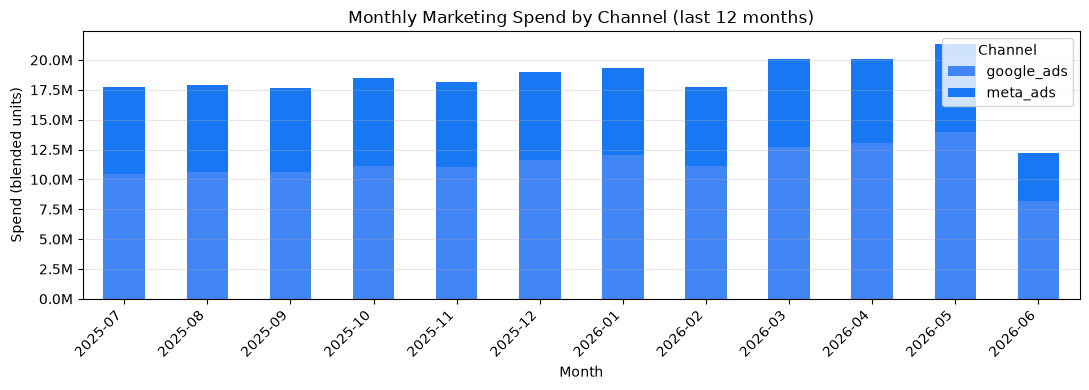

In [8]:
# Monthly marketing spend by channel (grouped bar, last 12 months available)
uc3_chan = q(f"""
    select date_trunc('month', report_date)::date as month,
           channel,
           sum(spend) as spend
    from {MARTS}.fct_marketing_spend_daily
    group by 1, 2
    order by 1
""")
pivot = uc3_chan.pivot(index="month", columns="channel", values="spend").fillna(0).tail(12)

fig, ax = plt.subplots(figsize=(11, 4))
pivot.plot(kind="bar", stacked=True, ax=ax, color=["#4285F4", "#1877F2"][: pivot.shape[1]])
ax.set_title("Monthly Marketing Spend by Channel (last 12 months)")
ax.set_xlabel("Month")
ax.set_ylabel("Spend (blended units)")
ax.set_xticklabels([d.strftime("%Y-%m") for d in pivot.index], rotation=45, ha="right")
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, p: f"{v/1e6:,.1f}M"))
ax.legend(title="Channel")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


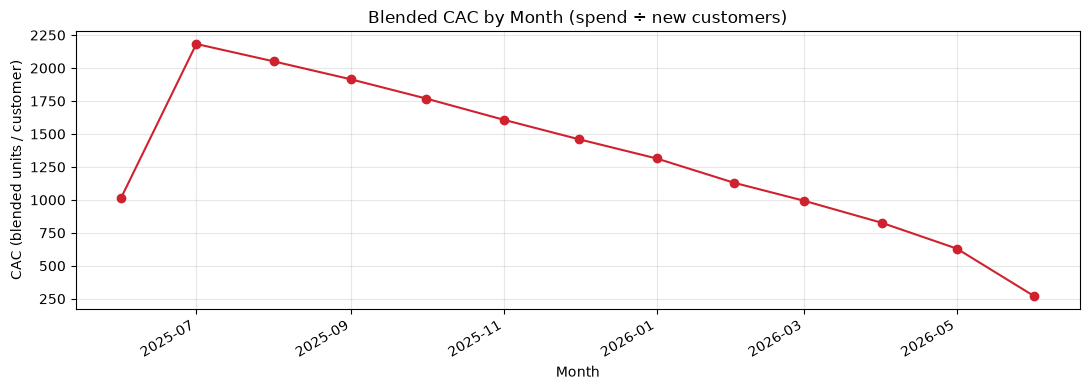

In [9]:
# Monthly blended CAC trend
spend_m = q(f"""
    select date_trunc('month', report_date)::date as month, sum(spend) as spend
    from {MARTS}.fct_marketing_spend_daily
    group by 1
""")
new_m = q(f"""
    select date_trunc('month', created_date)::date as month,
           count(distinct customer_id) as new_customers
    from {MARTS}.fct_transfers
    where is_first_transfer
    group by 1
""")
cac = spend_m.merge(new_m, on="month", how="inner").sort_values("month")
cac = cac[cac["new_customers"] > 0]
cac["cac"] = cac["spend"] / cac["new_customers"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cac["month"], cac["cac"], marker="o", color="#cf222e")
ax.set_title("Blended CAC by Month (spend ÷ new customers)")
ax.set_xlabel("Month")
ax.set_ylabel("CAC (blended units / customer)")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Interpretation.** Paid acquisition runs on **two channels — Google Ads and Meta Ads** — with Google carrying the larger share of spend. Blended CAC is computed against customers whose **first transfer** landed in the period (the true "activated paying customer"), which is the metric Growth should optimise rather than raw installs. The CAC trend reveals efficiency swings month-to-month: dips indicate spend converting more new payers, spikes flag either rising auction prices or weaker conversion. Note marketing spend only exists for the **trailing ~12 months** (2025-06 onward), so the CAC series is short and spend figures blend EUR/GBP/USD — directional, not a single-currency cost.

---
## Data lineage note

Each KPI traces back through the dbt model graph:

| Use case | Mart (this notebook reads) | Intermediate | Source-aligned |
|----------|----------------------------|--------------|----------------|
| **UC1 — Revenue** | `analytics_marts.fct_revenue_daily` | `int_revenue_per_transfer` | `int_transfers_enriched` |
| **UC2 — Risk** | `analytics_marts.dim_customer_risk` (+ `fct_kyc_checks`) | `int_customer_risk` | — |
| **UC3 — Marketing / CAC** | `analytics_marts.fct_marketing_spend_daily` (+ `fct_transfers`, `fct_acquisition_funnel`) | `int_marketing_spend_unioned` | — |

- **UC1:** `fct_revenue_daily` ← `int_revenue_per_transfer` ← `int_transfers_enriched`.
- **UC2:** `dim_customer_risk` ← `int_customer_risk`.
- **UC3:** `fct_marketing_spend_daily` ← `int_marketing_spend_unioned`. New-customer counts come from `fct_transfers.is_first_transfer`; `fct_acquisition_funnel` provides channel attribution (note: funnel is a sampled/attributed subset and is smaller than the full first-transfer customer count).

**Data surprises captured during build:**
- Revenue/spend totals are summed across mixed send currencies (EUR/GBP/USD/…) into blended units — not a single-currency figure.
- `dim_corridors` has no `corridor_name`; corridors are identified by `currency_pair`.
- Marketing spend exists only from **2025-06-18** onward and uses two channels (`google_ads`, `meta_ads`).
- `fct_acquisition_funnel.converted` count (Q1 ≈ 4.7k) is far below `fct_transfers.is_first_transfer` (Q1 ≈ 34.7k); the full transfer-level flag is used for CAC.